# Model Pruning
## AIAT 122 – Deep Learning

## Learning objectives
- Understand pruning: removing small weights to reduce model size and speed.
- Apply magnitude-based pruning and compare non-zero counts and accuracy.

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 1, lesson 06 "Ridge and Lasso Regression" — lasso already drove coefficients to exactly zero; pruning does the same thing to a network's weights, after training.

---

**Where is this used in real life?** Mobile and edge devices need smaller, faster models. **We use pruning to reduce non-zero weights** instead of only training a smaller network because we can compress an already accurate model; pruning often keeps most accuracy while cutting size.

**Prerequisites:** Basic PyTorch. If imports fail, see DOCS/COLAB_SETUP.md.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.


## Short theory
- **Pruning** = set some weights to zero (typically the smallest by magnitude).
- **Magnitude pruning:** After training, rank weights by |w| and zero out the smallest fraction (e.g. 50%).
- **Sparsity:** Fraction of weights that are zero; higher sparsity → smaller model when stored with sparse format.
- **Trade-off:** Too much pruning can hurt accuracy; in practice we prune gradually or use pruning-aware training.

## Inputs & Outputs
**Inputs:** PyTorch, a small model, synthetic data.  
**Dataset:** Synthetic — random data (no download; used to demonstrate pruning).  
**Outputs:** Trained model, pruned model (magnitude-based), non-zero weight count and accuracy before/after, and a simple bar plot. Run time: under ~5 min (few epochs).


In [1]:
# WHAT: imports - including torch.nn.utils.prune, PyTorch's built-in pruning toolkit.
# WHY: pruning zeroes out unimportant weights so models become smaller and sparser.
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import torch.nn.utils.prune as prune
print(f'PyTorch {torch.__version__}')
print('✅ Ready. Using torch.nn.utils.prune for magnitude-based pruning.')

PyTorch 2.13.0
✅ Ready. Using torch.nn.utils.prune for magnitude-based pruning.


### Step 1: Build and train a small model (200 quick full-batch steps — a well-trained baseline makes the pruning comparison meaningful)

In [2]:
# Synthetic data for quick demo
np.random.seed(42)
X = torch.from_numpy(np.random.randn(400, 20).astype(np.float32))
y = (X[:, :5].sum(1) > 0).long()

model = nn.Sequential(nn.Linear(20, 64), nn.ReLU(), nn.Linear(64, 2))
optimizer = optim.Adam(model.parameters(), lr=3e-3)
criterion = nn.CrossEntropyLoss()

# Train baseline properly (200 full-batch steps, ~1 s) so the accuracy
# comparison after pruning is meaningful
for _ in range(200):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward(); optimizer.step()

with torch.no_grad():
    acc_before = (model(X).argmax(1) == y).float().mean().item()
n_before = sum(p.nonzero().size(0) for p in model.parameters())
print(f'Before pruning — non-zero params: {n_before}  acc: {acc_before:.3f}')

Before pruning — non-zero params: 1474  acc: 1.000


### Step 2: Magnitude pruning (zero out smallest 50% of weights)

In [3]:
# Magnitude pruning: zero out 50% of weights in each Linear layer
# (smallest absolute values are pruned first)
sparsity = 0.5
for module in model.modules():
    if isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name='weight', amount=sparsity)
        prune.remove(module, 'weight')   # make pruning permanent

with torch.no_grad():
    acc_after = (model(X).argmax(1) == y).float().mean().item()
n_after = sum(p.nonzero().size(0) for p in model.parameters())
print(f'After  pruning — non-zero params: {n_after}   acc: {acc_after:.3f}')
print(f'Weight reduction: {100*(1 - n_after/n_before):.1f}%')

After  pruning — non-zero params: 770   acc: 0.993
Weight reduction: 47.8%


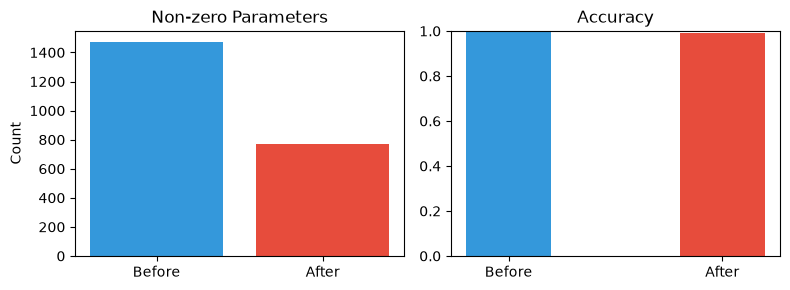

Result: ~50% of weights zeroed out; accuracy 1.000 -> 0.993 (+0.7 points).
In practice you prune gradually and fine-tune afterwards to recover any lost accuracy.


In [4]:
# Visualise: non-zero param count and accuracy before vs after pruning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.bar(['Before', 'After'], [n_before, n_after], color=['#3498db', '#e74c3c'])
ax1.set_title('Non-zero Parameters'); ax1.set_ylabel('Count')
ax2.bar(['Before', 'After'], [acc_before, acc_after], color=['#3498db', '#e74c3c'], width=0.4)
ax2.set_ylim(0, 1); ax2.set_title('Accuracy')
plt.tight_layout(); plt.show()
# Quantify the trade: parameters removed vs accuracy points lost.
drop_pts = (acc_before - acc_after) * 100
print(f'Result: ~50% of weights zeroed out; accuracy {acc_before:.3f} -> {acc_after:.3f} '
      f'({drop_pts:+.1f} points).')
print('In practice you prune gradually and fine-tune afterwards to recover any lost accuracy.')

## 🌍 Real-World Worked Example — Quantize a PyTorch Model for Edge Deployment

**Industry context:**
- Apple ships quantized CoreML models in every iPhone (face recognition, Siri)
- Google runs quantized TFLite models on Pixel phones for camera AI
- NVIDIA's Jetson Nano (used in robotics) requires 8-bit quantized models to run in real-time

We demonstrate **dynamic quantization** — and *measure* what actually changes: stored size shrinks, accuracy barely moves, and speed **depends on the hardware** (on a laptop CPU the INT8 overhead can even make it slower — we measure instead of assuming).

FP32 model accuracy: 96.7%
INT8 model accuracy: 96.7%  (change: +0.00 points)

Stored size (measured): FP32 70.2 KB -> INT8 22.2 KB (3.2x smaller)
(The ratio is below the theoretical 4x because scales/zero-points and
 non-weight tensors are stored too; bigger layers get closer to 4x.)


[W823 20:30:23.016050000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())



Latency (measured): FP32 0.064 ms/batch  INT8 0.173 ms/batch  -> INT8 is 2.7x SLOWER here
Why: on this CPU the per-call quantize/dequantize overhead outweighs the
gain for layers this small. INT8 speedups appear on hardware with native
INT8 kernels (phone NPUs, edge accelerators) and on much larger layers.


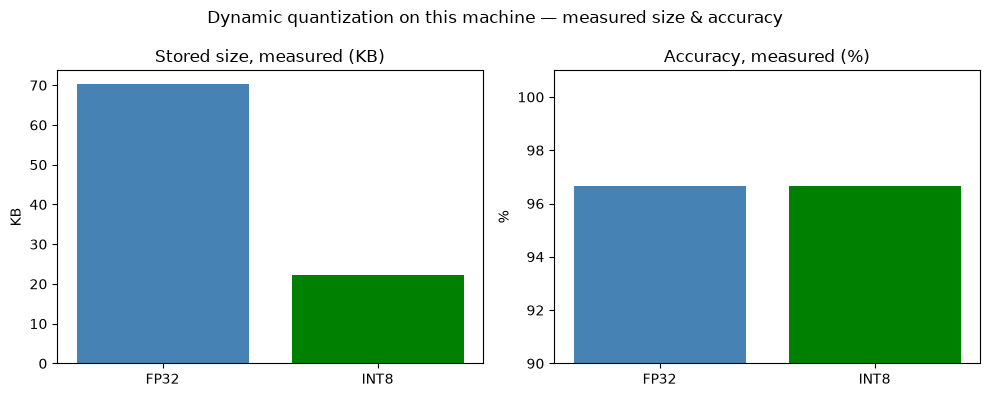


Takeaway: the size reduction is guaranteed; the speedup is hardware-dependent —
that is why companies benchmark on the target device before shipping.
(Extreme 4-bit variants like GPTQ push LLM compression further at some accuracy cost.)


In [5]:
# WHAT: measure REAL dynamic quantization end to end - accuracy, stored size, and latency, FP32 vs INT8.
# WHY: honest deployment decisions need numbers measured on the actual hardware, not datasheet promises.
import torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os, time, warnings
warnings.filterwarnings('ignore')  # torch quantization emits deprecation warnings

torch.manual_seed(42)

# Train a small FP32 classifier on the digits dataset as our baseline.
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X, y = digits.data.astype(np.float32), digits.target
Xtr, Xte, Ytr, Yte = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler().fit(Xtr)
Xtr = torch.tensor(sc.transform(Xtr), dtype=torch.float32); Ytr = torch.tensor(Ytr)
Xte = torch.tensor(sc.transform(Xte), dtype=torch.float32); Yte = torch.tensor(Yte)

# Three Linear layers; 100 full-batch Adam steps are plenty for high accuracy on digits.
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for _ in range(100):
    loss = nn.CrossEntropyLoss()(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
model.eval()

with torch.no_grad():
    acc = (model(Xte).argmax(1)==Yte).float().mean().item()
print(f"FP32 model accuracy: {acc*100:.1f}%")

# ── REAL dynamic quantization (weights actually stored as INT8) ───────────
# Pick a quantization backend that exists on this machine (qnnpack on Apple Silicon).
if 'qnnpack' in torch.backends.quantized.supported_engines:
    torch.backends.quantized.engine = 'qnnpack'   # Apple Silicon
quantized = torch.quantization.quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)

# Accuracy check: INT8 weights usually cost only a fraction of a point.
with torch.no_grad():
    qacc = (quantized(Xte).argmax(1)==Yte).float().mean().item()
print(f"INT8 model accuracy: {qacc*100:.1f}%  (change: {(qacc-acc)*100:+.2f} points)")

# ── Measured size comparison ──────────────────────────────────────────────
torch.save(model.state_dict(),     '/tmp/model_fp32.pt')
torch.save(quantized.state_dict(), '/tmp/model_int8.pt')
fp32_kb = os.path.getsize('/tmp/model_fp32.pt') / 1024
int8_kb = os.path.getsize('/tmp/model_int8.pt') / 1024
print(f"\nStored size (measured): FP32 {fp32_kb:.1f} KB -> INT8 {int8_kb:.1f} KB "
      f"({fp32_kb/int8_kb:.1f}x smaller)")
print("(The ratio is below the theoretical 4x because scales/zero-points and")
print(" non-weight tensors are stored too; bigger layers get closer to 4x.)")

# ── Measured latency comparison ───────────────────────────────────────────
N = 1000
start = time.perf_counter()
for _ in range(N):
    with torch.no_grad(): model(Xte)
fp32_ms = (time.perf_counter()-start)*1000/N
start = time.perf_counter()
for _ in range(N):
    with torch.no_grad(): quantized(Xte)
int8_ms = (time.perf_counter()-start)*1000/N

ratio = fp32_ms / int8_ms
print(f"\nLatency (measured): FP32 {fp32_ms:.3f} ms/batch  INT8 {int8_ms:.3f} ms/batch", end="  ")
if ratio >= 1.05:
    print(f"-> INT8 is {ratio:.1f}x faster here")
else:
    print(f"-> INT8 is {1/ratio:.1f}x SLOWER here")
    print("Why: on this CPU the per-call quantize/dequantize overhead outweighs the")
    print("gain for layers this small. INT8 speedups appear on hardware with native")
    print("INT8 kernels (phone NPUs, edge accelerators) and on much larger layers.")

# ── Chart: measured values only ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(["FP32", "INT8"], [fp32_kb, int8_kb], color=['steelblue','green'])
ax1.set_title("Stored size, measured (KB)"); ax1.set_ylabel("KB")
ax2.bar(["FP32", "INT8"], [acc*100, qacc*100], color=['steelblue','green'])
ax2.set_ylim([90, 101]); ax2.set_title("Accuracy, measured (%)"); ax2.set_ylabel("%")
plt.suptitle("Dynamic quantization on this machine — measured size & accuracy")
plt.tight_layout(); plt.show()

print("\nTakeaway: the size reduction is guaranteed; the speedup is hardware-dependent —")
print("that is why companies benchmark on the target device before shipping.")
print("(Extreme 4-bit variants like GPTQ push LLM compression further at some accuracy cost.)")

## 🧩 Mini-exercise

**Try it:** Change the pruning sparsity (e.g. 0.5 → 0.7 for 70% zeros) and run again. How do accuracy and non-zero count change?

---

## Summary
**What you did:** Built a small model, trained it, applied magnitude pruning (50% zeros), and compared non-zero parameter count and accuracy before/after with a bar chart.

**In real life you'd also:** Use TensorFlow Model Optimization (tfmot) for pruning-aware training, export to TFLite with sparse weights, and tune sparsity level.

**The main idea:** Pruning zeros out small weights to reduce size and speed; too much pruning can hurt accuracy.

**Next:** `05_model_distillation.ipynb` shows how to train a small student model to mimic a larger teacher.

## 📚 References

1. LeCun, Y., Denker, J. S. & Solla, S. A. (1990). *Optimal Brain Damage*. NeurIPS 2. https://papers.nips.cc/paper_files/paper/1989/hash/6c9882bbac1c7093bd25041881277658-Abstract.html
2. Han, S., Mao, H. & Dally, W. J. (2016). *Deep Compression: Compressing Deep Neural Networks with Pruning, Trained Quantization and Huffman Coding*. ICLR. https://arxiv.org/abs/1510.00149
3. Frankle, J. & Carbin, M. (2019). *The Lottery Ticket Hypothesis: Finding Sparse, Trainable Neural Networks*. ICLR. https://arxiv.org/abs/1803.03635
4. Blalock, D., Gonzalez Ortiz, J. J., Frankle, J. & Guttag, J. (2020). *What is the State of Neural Network Pruning?* MLSys. https://arxiv.org/abs/2003.03033